In [3]:
import os
import csv
import pandas as pd 
import numpy as np 

#train - test split 
from sklearn.model_selection import train_test_split

#random forest model 
from sklearn.ensemble import RandomForestRegressor

#metrics 
from sklearn.metrics import r2_score, mean_squared_error

c:\Users\A1990\anaconda3\envs\dev\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
file_path = os.path.join("realtor_modeling", "realtor_master")

In [5]:
random_df = pd.read_csv("../realtor_modeling.csv")
random_df

,price,bed,bath,acre_lot,house_size,state_Alaska,state_Arizona,state_Arkansas,state_California,state_Colorado,...,zip3_982,zip3_983,zip3_986,zip3_other,status_ready_to_build,status_sold,price_per_sqft,bath_per_bed,rooms_total,lot_to_size
0,395000.0,4.0,4.0,0.35,2884.0,False,False,False,False,False,...,False,False,False,True,False,False,136.962552,1.000000,8.0,0.000121
1,370000.0,3.0,3.0,2.80,2700.0,False,False,False,False,False,...,False,False,False,True,False,False,137.037037,1.000000,6.0,0.001037
2,1550000.0,5.0,3.0,0.12,3000.0,False,False,False,True,False,...,False,False,False,True,False,True,516.666667,0.600000,8.0,0.000040
3,88000.0,2.0,2.0,0.19,1069.0,False,False,False,False,False,...,False,False,False,True,False,False,82.319925,1.000000,4.0,0.000178
4,1595000.0,2.0,1.0,0.06,1665.0,False,False,False,True,False,...,False,False,False,True,False,False,957.957958,0.500000,3.0,0.000036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99983,370000.0,4.0,3.0,0.17,2107.0,False,False,False,False,False,...,False,False,False,True,False,True,175.605126,0.750000,7.0,0.000081
99984,249900.0,3.0,3.0,0.20,2554.0,False,False,False,False,False,...,False,False,False,True,False,False,97.846515,1.000000,6.0,0.000078
99985,75000.0,4.0,1.0,0.51,680.0,False,False,False,False,False,...,False,False,False,True,False,False,110.294118,0.250000,5.0,0.000750
99986,28000.0,3.0,2.0,1.00,1760.0,False,False,False,False,False,...,False,False,False,True,False,False,15.909091,0.666667,5.0,0.000568


In [6]:
random_df.isnull().sum()

price             0
bed               0
bath              0
acre_lot          0
house_size        0
                 ..
status_sold       0
price_per_sqft    0
bath_per_bed      0
rooms_total       0
lot_to_size       0
Length: 164, dtype: int64

In [7]:
random_df.dtypes

price             float64
bed               float64
bath              float64
acre_lot          float64
house_size        float64
                   ...   
status_sold          bool
price_per_sqft    float64
bath_per_bed      float64
rooms_total       float64
lot_to_size       float64
Length: 164, dtype: object

In [8]:
print(len(random_df))

99988


In [9]:
# Sample dataset
sample_size = min(100000, len(random_df))
sample_df = random_df.sample(sample_size, random_state=25)


sample_df = sample_df[sample_df["house_size"] > 0]
sample_df = sample_df[sample_df["price"] > 0]
sample_df = sample_df[sample_df["bed"] <= 10]
sample_df = sample_df[sample_df["bath"] <= 10]
sample_df = sample_df[sample_df["house_size"] < 10000]


#Define X and Y
X = sample_df.drop(["price", "price_per_sqft"], axis=1)
y= np.log(sample_df["price"])

#Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=25
)


#random Forest model 
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=1200,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=25
)

# Train (IMPORTANT: X_train)
model_rf.fit(X_train, y_train)

# Predict
y_pred = model_rf.predict(X_test)

# Evaluate
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print("Random Forest R²:", r2)

Random Forest R²: 0.6153033747963134


In [10]:
# Define X and y
#X = random_df.drop("price", axis=1)
#y = random_df["price"]

In [11]:
#training the dataset (70 %) and test it with (30%) remaining 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=50
)

In [12]:
#Dataset too large to run on my pc - I run it for 30+ minutes before I interrupted the kernel. Helped me validated the process!!!

#creating our LM model 
#model_rf = RandomForestRegressor(n_estimators=100, random_state=50)

#model_rf.fit(X_train, y_train)

#y_pred = model_rf.predict(X_test)

In [13]:
#Displaying the results 
#r2 = r2_score(y_test, y_pred)
#print("Random Forest R²:", r2)

In [14]:
import pickle

# Save model to file
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(model_rf, f)

In [15]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(10))

              feature  importance
1                bath    0.298374
3          house_size    0.217432
161       lot_to_size    0.099828
2            acre_lot    0.090587
7    state_California    0.052547
160       rooms_total    0.025693
36     state_New York    0.022374
156        zip3_other    0.022192
159      bath_per_bed    0.011290
158       status_sold    0.009740


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# =========================
# 1) Evaluate on original scale
# =========================

# Predict (already trained model_rf)
y_pred = model_rf.predict(X_test)

# Convert back from log
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred)

# Metrics
r2_orig = r2_score(y_test_orig, y_pred_orig)
mae = mean_absolute_error(y_test_orig, y_pred_orig)

print("R² (original scale):", r2_orig)
print("MAE ($):", mae)


# =========================
# 2) Feature Engineering (SAFE)
# =========================



# =========================
# Rebuild X and y
# =========================

X = sample_df.drop(["price", "price_per_sqft"], axis=1)
y = np.log(sample_df["price"])

# Split again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=25
)

# =========================
# 3) Retrain Random Forest (tuned)
# =========================

model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=25
)

model_rf.fit(X_train, y_train)

# Predict again
y_pred = model_rf.predict(X_test)

# Evaluate log scale
print("R² (log scale):", r2_score(y_test, y_pred))

# Convert back to original scale
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred)

print("R² (original scale):", r2_score(y_test_orig, y_pred_orig))
print("MAE ($):", mean_absolute_error(y_test_orig, y_pred_orig))


# =========================
# 4) Cross Validation (model stability)
# =========================

scores = cross_val_score(model_rf, X, y, cv=5, scoring="r2", n_jobs=-1)

print("CV R² mean:", scores.mean())
print("CV R² std:", scores.std())


# =========================
# 5) OPTIONAL: Gradient Boosting Model
# =========================

gbr = GradientBoostingRegressor(random_state=25)
gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

print("Gradient Boosting R² (log):", r2_score(y_test, gbr_pred))

# Back-transform
gbr_pred_orig = np.exp(gbr_pred)

print("Gradient Boosting R² (original):", r2_score(y_test_orig, gbr_pred_orig))
print("Gradient Boosting MAE ($):", mean_absolute_error(y_test_orig, gbr_pred_orig))

R² (original scale): 0.2329697889790585
MAE ($): 175512.54862365412
R² (log scale): 0.6151227871499995
R² (original scale): 0.26330050491614987
MAE ($): 218208.65499609793
CV R² mean: 0.6240778965994925
CV R² std: 0.006651619998622336
Gradient Boosting R² (log): 0.5388068019269903
Gradient Boosting R² (original): 0.18757307485169483
Gradient Boosting MAE ($): 242385.1623070141


## Final Visualizations for Model Evaluation

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt

visuals_dir = Path(r"C:\Users\A1990\Dev\BUSA - Capstone 695\realtor_random_forest.ipynb\visuals")
visuals_dir.mkdir(exist_ok=True)


### 1. Actual vs Predicted Home Prices (Random Forest)

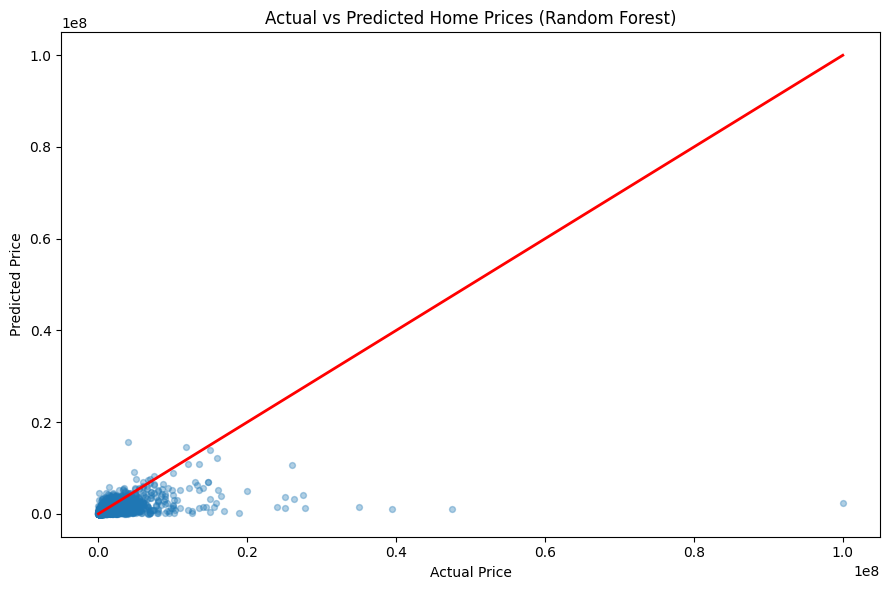

In [18]:
actual_min = min(y_test_orig.min(), y_pred_orig.min())
actual_max = max(y_test_orig.max(), y_pred_orig.max())

plt.figure(figsize=(9, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.35, s=18)
plt.plot([actual_min, actual_max], [actual_min, actual_max], color="red", linewidth=2)
plt.title("Actual vs Predicted Home Prices (Random Forest)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.tight_layout()
plt.savefig(visuals_dir / "actual_vs_predicted_rf.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 2. Residual Distribution

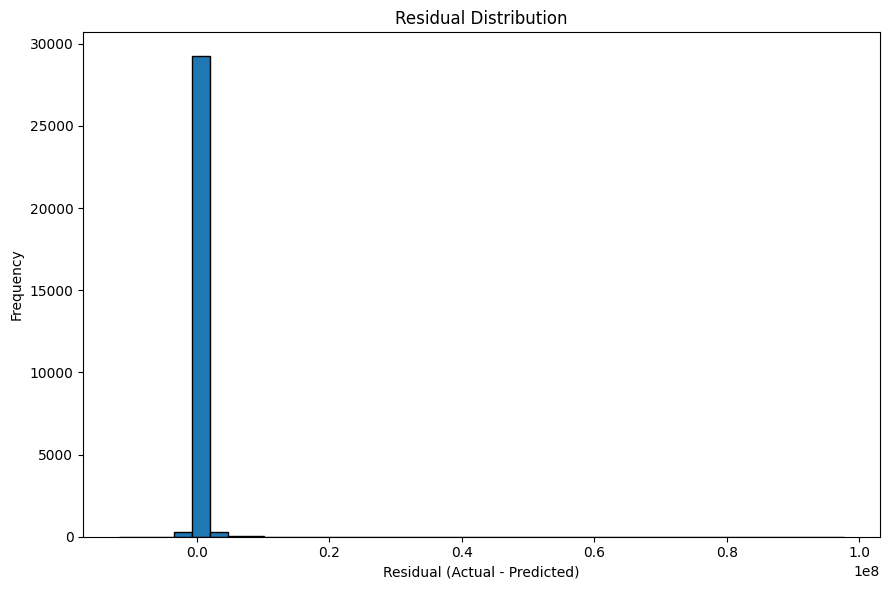

In [19]:
residuals = y_test_orig - y_pred_orig

plt.figure(figsize=(9, 6))
plt.hist(residuals, bins=40, edgecolor="black")
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(visuals_dir / "residual_distribution_rf.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 3. Residuals vs Predicted Price

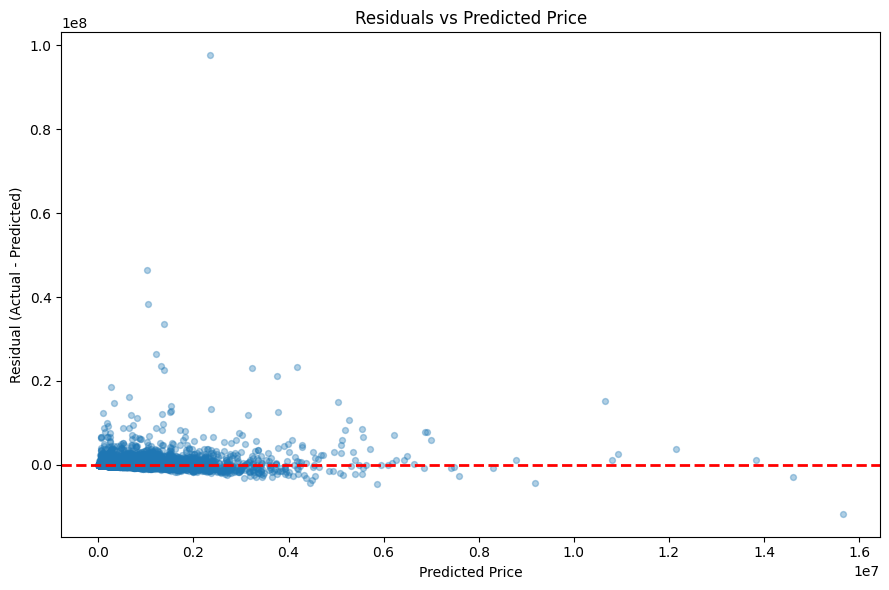

In [20]:
plt.figure(figsize=(9, 6))
plt.scatter(y_pred_orig, residuals, alpha=0.35, s=18)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.title("Residuals vs Predicted Price")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.savefig(visuals_dir / "residuals_vs_predicted_rf.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 4. Top 15 Feature Importances

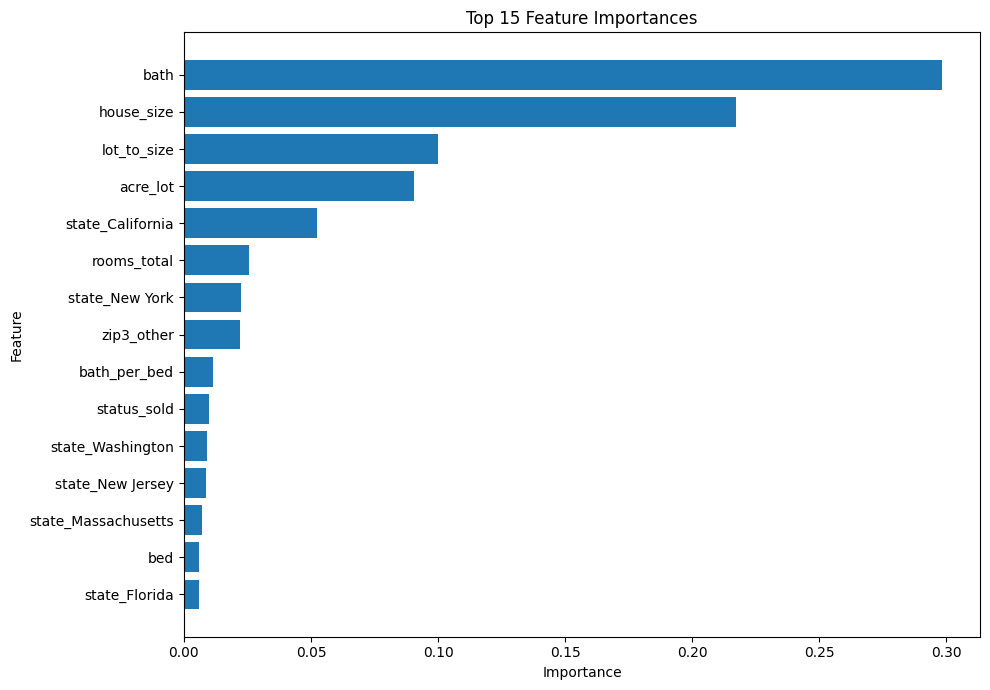

In [21]:
top_features = feature_importance.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(visuals_dir / "feature_importance_top15_rf.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 5. Model Performance Comparison

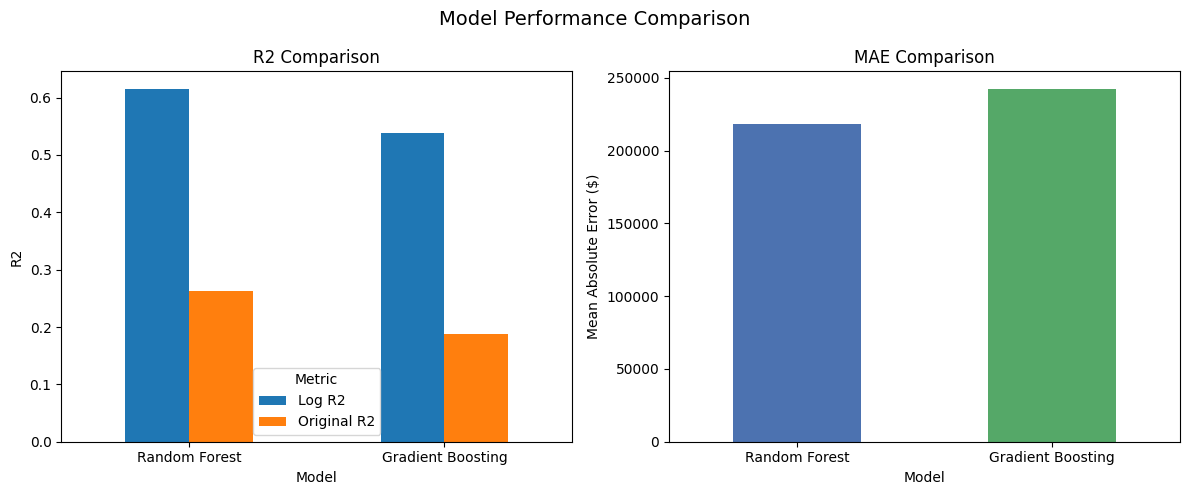

In [22]:
performance_df = pd.DataFrame(
    {
        "Model": ["Random Forest", "Gradient Boosting"],
        "Log R2": [r2_score(y_test, y_pred), r2_score(y_test, gbr_pred)],
        "Original R2": [r2_score(y_test_orig, y_pred_orig), r2_score(y_test_orig, gbr_pred_orig)],
        "MAE": [mean_absolute_error(y_test_orig, y_pred_orig), mean_absolute_error(y_test_orig, gbr_pred_orig)],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
performance_df.plot(x="Model", y=["Log R2", "Original R2"], kind="bar", ax=axes[0], rot=0)
axes[0].set_title("R2 Comparison")
axes[0].set_ylabel("R2")
axes[0].legend(title="Metric")

performance_df.plot(x="Model", y="MAE", kind="bar", ax=axes[1], rot=0, color=["#4C72B0", "#55A868"], legend=False)
axes[1].set_title("MAE Comparison")
axes[1].set_ylabel("Mean Absolute Error ($)")

fig.suptitle("Model Performance Comparison", fontsize=14)
fig.tight_layout()
fig.savefig(visuals_dir / "model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


### 6. Cross-Validation R² Distribution

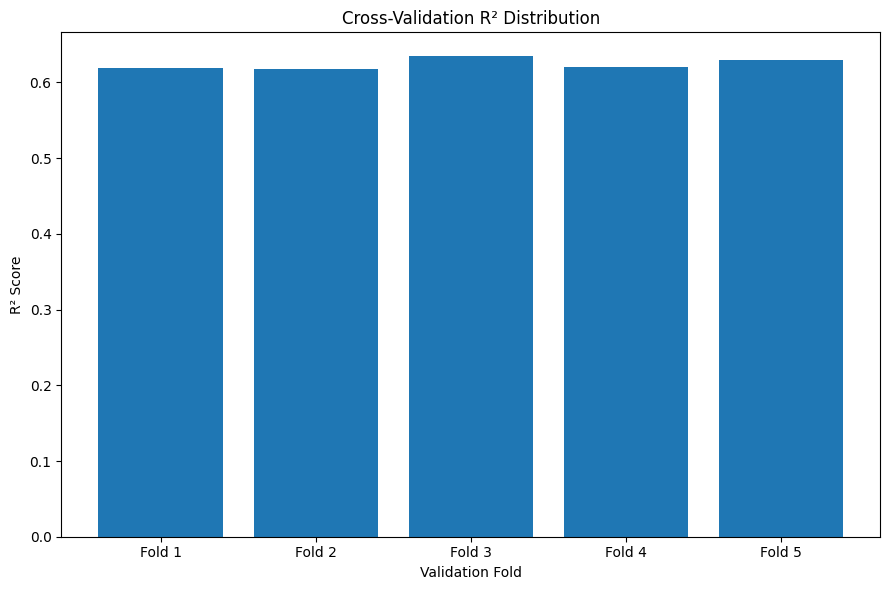

In [23]:
cv_scores_df = pd.DataFrame(
    {
        "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
        "R2 Score": scores,
    }
)

plt.figure(figsize=(9, 6))
plt.bar(cv_scores_df["Fold"], cv_scores_df["R2 Score"])
plt.title("Cross-Validation R² Distribution")
plt.xlabel("Validation Fold")
plt.ylabel("R² Score")
plt.tight_layout()
plt.savefig(visuals_dir / "cross_validation_r2_scores.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [24]:
import datetime

# Create timestamp
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Build results text
results_text = f"""
===============================
MODEL RESULTS SUMMARY
===============================

Timestamp: {timestamp}

--- Random Forest ---
R² (log scale): {r2_score(y_test, y_pred):.6f}
R² (original scale): {r2_score(y_test_orig, y_pred_orig):.6f}
MAE ($): {mean_absolute_error(y_test_orig, y_pred_orig):,.2f}

--- Cross Validation ---
CV R² mean: {scores.mean():.6f}
CV R² std: {scores.std():.6f}

--- Gradient Boosting ---
R² (log scale): {r2_score(y_test, gbr_pred):.6f}
R² (original scale): {r2_score(y_test_orig, gbr_pred_orig):.6f}
MAE ($): {mean_absolute_error(y_test_orig, gbr_pred_orig):,.2f}

===============================
END OF RESULTS
===============================
"""

# Save to file
with open("model_results.txt", "a") as f:
    f.write(results_text)

print("✅ Results saved to model_results.txt")

✅ Results saved to model_results.txt
